# Color Alpha Support

Lets-Plot accepts color values that include an alpha channel. This makes it possible to keep the same base color while controlling transparency for annotations, labels, and other plot elements.

The alpha component can be embedded directly in the color string in the following formats:

| Format | Example | Alpha range |
|--------|---------|-------------|
| `name / a` | `steelblue / 0.14` | float 0.0 (transparent) – 1.0 (opaque) |
| `rgba(r, g, b, a)` | `rgba(70, 130, 180, 0.14)` | float 0.0 (transparent) – 1.0 (opaque) |
| `#RRGGBBAA` | `#4682B424` | hex byte 00–FF |
| `#RGBA` | `#48B2` | hex nibble 0–F (expanded to `#4488BB22`) |
| `color(r, g, b, a)` | `color(70, 130, 180, 0.14)` | float 0.0 – 1.0 |

For alpha, zero means a transparent color, and 1.0 (hex FF) means opaque. Some of these formats also work without the alpha component for fully opaque colors (`green`, `rgb(...)`, `#RRGGBB`, `#RGB`).


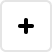
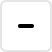
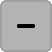
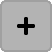
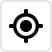
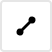
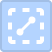
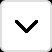
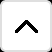
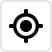
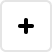
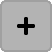
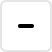
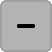
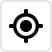
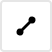
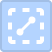
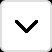
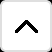
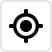

In [1]:
from datetime import date
from lets_plot import *

LetsPlot.setup_html()

In [2]:
months = [date(2024, m, 1) for m in range(1, 7)]

forecast = {
    'month': months,
    'leads': [18, 29, 41, 57, 63, 74],
    'lead_label': ['18k', '29k', '41k', '57k', '63k', '74k']
}

series_color = 'steelblue'
area_fill = 'mediumturquoise'
paper = 'aliceblue'
muted_text = 'slategray'
title_text = 'midnightblue'

base_plot = (
    ggplot(forecast, aes('month', 'leads'))
    + geom_area(fill=area_fill, alpha=0.35)
    + geom_line(color=series_color, size=2.2)
    + geom_point(color=series_color, fill='white', shape=21, size=4.5, stroke=1.6)
    + geom_text(
        aes(label='lead_label'),
        nudge_y=6,
        size=10,
        color=series_color
    )
    + scale_x_datetime(breaks=months, format='%b')
    + scale_y_continuous(limits=[0, 86], breaks=[0, 20, 40, 60, 80])
    + ggsize(760, 420)
    + theme(
        plot_background=element_rect(fill=paper, color=paper),
        panel_background=element_rect(fill=paper, color=paper),
        panel_grid_minor=element_blank(),
        panel_grid_major_x=element_blank(),
        axis_text=element_text(color=muted_text),
        axis_title_y=element_text(color=muted_text),
        plot_title=element_text(color=title_text, face='bold', size=20),
        plot_subtitle=element_text(color=muted_text, size=11)
    )
)

## Plot Tag

Here, the plot tag receives a translucent color value directly from `rgba(...)`.


In [3]:
(
    base_plot
    + labs(
        title='Partner pipeline forecast',
        subtitle='The semi-transparent tag color is specified with an alpha channel',
        tag='DRAFT',
        x='',
        y='Qualified leads'
    )
    + theme(
        plot_tag=element_text(
            
            color='rgba(70, 130, 180, 0.14)',   # <-- alpha is part of the color value
            
            face='bold',
            size=180,
            angle=40,
        ),
        plot_tag_location='panel',
        plot_tag_position=[0.5, 0.5]
    )
)


## Geom Text

The same plot can place the translucent annotation in an inclined `geom_text()` layer instead of using the plot tag.

**Note.** Each annotation row carries its own color string, using one of different alpha-enabled formats 
that represent nearly the same color. The colors are mapped with `scale_color_identity()`.

In [4]:
alpha_df = {
    "x": [date(2024, 5, 5), date(2024, 3, 15), date(2024, 3, 18), date(2024, 1, 29)],
    "y": [62.5, 62.5, 28.5, 28.5],
    "label": ["ALPHA"] * 4,
    "color": [
        'steelblue / 0.14',           # named color + alpha
        'rgba(70, 130, 180, 0.14)',   # rgba(...) with float alpha
        '#4682B424',                  # #RRGGBBAA hex
        '#48B2'                       # #RGBA short hex, almost the same appearance
    ],
}

(
    base_plot
    + geom_text(data=alpha_df,
        mapping=aes("x", "y", label="label", color="color"),
        inherit_aes=False,
        size=34,
        angle=-30,
        fontface='bold'
    )
    + scale_color_identity()
    + labs(
        title='Partner pipeline forecast',
        subtitle='Each geom_text row uses a different alpha-enabled color format',
        x='',
        y='Qualified leads'
    )
)